# Configuration settings

In [1]:
from pathlib import Path

# -------- Save-or-load wrapper --------
regenerate = True
# regenerate = False

# seed_identifier = "seed1"
seed_identifier = "seed2"
carla_run_identifier = "separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy"
# network_configuration = "bw10mbit_delay0_jitter0_loss0"
network_configuration = "bw100mbit_delay20_jitter5_loss0"
print(f"doing dataset: {network_configuration}")
device = "cuda:0"
DATA_ROOT = Path(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/indexed_samples/packetsizes") / network_configuration
MUST_CONTAIN = ["video_camera", "pkts"]

OUTPUT_TENSORS_ROOT = Path(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/tensors/packetsizes/{network_configuration}")
GROUPING_TRAINING_TENSORS_ROOT = OUTPUT_TENSORS_ROOT / "packet_grouping_training_tensors"
GROUPING_TRAINING_TENSORS_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_DIR = OUTPUT_TENSORS_ROOT / "packet_grouping_model_weights"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_SAVE_DIR / "best_packetsegformer.pkl"

doing dataset: bw100mbit_delay20_jitter5_loss0


# Preprocessing

In [2]:
from typing import List, Tuple, Optional, Dict
import numpy as np
import pandas as pd
import torch
import json

# Required columns now include rtp.marker
REQUIRED_COLS = ["frame.time_relative", "frame.len", "rtp.marker"]

def find_candidate_csvs(root: str | Path,
                        pattern: str = "*.csv",
                        must_contain: Optional[List[str]] = None) -> List[Path]:
    root = Path(root).expanduser().resolve()
    all_csvs = sorted(p for p in root.rglob(pattern) if p.is_file())
    if must_contain:
        all_csvs = [p for p in all_csvs if any(m in p.name for m in must_contain)]
    return all_csvs

def file_has_required_cols(path: Path) -> bool:
    try:
        sample = pd.read_csv(path, nrows=20)
        return all(c in sample.columns for c in REQUIRED_COLS)
    except Exception:
        return False

def read_one_csv(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """
    Read one CSV and return:
      X_norm: [N, 2] float32 -> [frame.time_relative (absolute), frame.len]
      marker: [N]     bool    -> rtp.marker (True marks the *last* packet of a frame)
    Notes:
      - We will convert X_norm[:,0] (absolute times) into deltas later,
        and shift all targets by one to align with "time since previous packet".
    """
    df = pd.read_csv(
        path,
        usecols=REQUIRED_COLS,
        dtype={
            "frame.time_relative": "float64",
            "frame.len": "float64",
            "rtp.marker": "object",  # robust: handle 0/1, "True"/"False"
        },
    )

    # Normalize marker to boolean
    # Accepts: 1/0, "1"/"0", "true"/"false", True/False
    def _to_bool(v):
        if pd.isna(v):
            return False
        if isinstance(v, (int, np.integer, bool, np.bool_)):
            return bool(v)
        s = str(v).strip().lower()
        return s in ("1", "true", "t", "yes", "y")

    df["rtp.marker"] = df["rtp.marker"].map(_to_bool)

    df = df.dropna(subset=["frame.time_relative", "frame.len"])
    if df.empty:
        return np.zeros((0, 2), dtype=np.float32), np.zeros((0,), dtype=bool)

    # Sort by time (stable)
    df = df.sort_values("frame.time_relative", kind="mergesort")

    X_norm = df[["frame.time_relative", "frame.len"]].to_numpy(dtype=np.float32)  # [N,2]
    marker = df["rtp.marker"].to_numpy(dtype=bool)                                # [N]
    return X_norm, marker

def build_padded_packet_tensors(
    root: str | Path,
    pattern: str = "*.csv",
    must_contain: Optional[List[str]] = None,  # e.g., ["video_camera", "pkts"]
    device_preference: str = "cuda",
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, List[Path], np.ndarray, np.ndarray]:
    """
    Returns:
      X:                 [S, N_max, 2] float32 on device (Δtime_since_prev, frame.len), PAD = -1.0
      y:                 [S, N_max]    bool    on device (boundary=True/False),       PAD = False
      mask:              [S, N_max]    bool    on device (True = real, False = pad)
      frame_assignments: [S, N_max]    int64   on device (frame_id 0..F_i-1),         PAD = -1
      paths:             list[Path]
      lengths:           np.ndarray[S] original per-file *post-shift* lengths (N_i - 1)
      num_frames:        np.ndarray[S] total frames per file (sum of markers, with last forced)
    """
    # 1) Find viable CSVs
    candidates = find_candidate_csvs(root, pattern=pattern, must_contain=must_contain)
    viable = [p for p in candidates if file_has_required_cols(p)]
    if not viable:
        raise RuntimeError("No CSVs with required columns found under the root path.")
    print(f"Found {len(viable)} CSV(s) with required columns.")

    per_X: List[np.ndarray] = []
    per_frame_ids: List[np.ndarray] = []
    per_boundary: List[np.ndarray] = []
    lengths: List[int] = []
    num_frames_list: List[int] = []

    # 2) Process each CSV using rtp.marker
    for i, p in enumerate(viable, 1):
        try:
            X_norm, marker = read_one_csv(p)  # X_norm: [N,2], marker: [N] bool (end-of-frame)
            N = X_norm.shape[0]
            if N == 0:
                # empty
                per_X.append(np.zeros((0, 2), dtype=np.float32))
                per_frame_ids.append(np.zeros((0,), dtype=np.int64))
                per_boundary.append(np.zeros((0,), dtype=bool))
                lengths.append(0)
                num_frames_list.append(0)
                continue

            # Ensure the last packet ends a frame (if not already)
            if not marker[-1]:
                marker = marker.copy()
                marker[-1] = True

            # ---------------------------
            # Frame assignments from marker:
            #   - marker marks the LAST packet of a frame
            #   - the marker packet belongs to the PRECEDING frame
            #   - frame id increments *after* a marker
            # So frame_id[i] = cumsum(prev_marker up to i-1), starting at 0
            prev_marker = np.concatenate([[0], marker[:-1].astype(np.int64)], axis=0)  # [N]
            frame_ids = np.cumsum(prev_marker).astype(np.int64)  # 0..F-1
            F_i = int(marker.sum())  # total frames
            # ---------------------------

            # Boundaries (end-of-frame) are directly the marker flags
            bvec = marker.astype(bool)  # [N] True where frame ends

            # ---------------------------
            # Build Δtime feature and align targets:
            #   X = [Δtime, frame.len] for indices 1..N-1
            #   frame_assignments = frame_ids[1:]
            #   boundary y = bvec[1:]  (boundary at current index)
            # ---------------------------
            abs_t = X_norm[:, 0].astype(np.float32)  # absolute times
            pkt_sz = X_norm[:, 1].astype(np.float32)
            dt = abs_t[1:] - abs_t[:-1]             # [N-1]
            X_win = np.stack([dt, pkt_sz[1:]], axis=1).astype(np.float32)  # [N-1,2]

            fa_shift = frame_ids[1:].astype(np.int64)  # [N-1]
            b_shift  = bvec[1:].astype(bool)           # [N-1]

            per_X.append(X_win)
            per_frame_ids.append(fa_shift)
            per_boundary.append(b_shift)
            lengths.append(len(fa_shift))  # N-1
            num_frames_list.append(F_i)
        except Exception as e:
            print(f"  ! Skipping {p} due to error: {e}")

    if not per_X:
        raise RuntimeError("All candidate CSVs failed to load.")

    lengths = np.asarray(lengths, dtype=np.int64)
    num_frames = np.asarray(num_frames_list, dtype=np.int64)
    S = len(per_X)
    N_max = int(lengths.max() if lengths.size else 0)
    print(f"Sequences: {S} | Max length: {N_max}")

    # 3) Allocate padded arrays (CPU first)
    X_pad  = np.full((S, N_max, 2), fill_value=-1.0, dtype=np.float32)
    y_pad  = np.zeros((S, N_max), dtype=bool)           # boundary: pad=False
    fa_pad = np.full((S, N_max), fill_value=-1, dtype=np.int64)
    mask   = np.zeros((S, N_max), dtype=bool)

    # 4) Fill with per-file data
    for s, (Xi, fa_i, b_i) in enumerate(zip(per_X, per_frame_ids, per_boundary)):
        n = len(fa_i)
        if n == 0:
            continue
        X_pad[s, :n, :] = Xi
        fa_pad[s, :n]   = fa_i
        y_pad[s,  :n]   = b_i
        mask[s,   :n]   = True

    # 5) Move to target device
    device = (
        torch.device(device_preference) if device_preference == "cpu"
        else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    )
    X = torch.from_numpy(X_pad).to(device, dtype=torch.float32, non_blocking=True)
    y = torch.from_numpy(y_pad).to(device, dtype=torch.bool,     non_blocking=True)  # boundary bool (end-of-frame)
    mask_t = torch.from_numpy(mask).to(device, non_blocking=True)
    frame_assignments = torch.from_numpy(fa_pad).to(device, dtype=torch.int64, non_blocking=True)

    return X, y, mask_t, frame_assignments, viable, lengths, num_frames

# ---------- Helpers to save/load a prepared dataset (unchanged) ----------
def save_dataset(save_dir: Path, X: torch.Tensor, y: torch.Tensor, mask: torch.Tensor,
                 paths: list[Path], lengths: np.ndarray, num_frames: np.ndarray,
                 frame_assignments: torch.Tensor):
    save_dir.mkdir(parents=True, exist_ok=True)

    X_to_save  = X.detach()
    y_to_save  = y.detach().to(torch.bool)
    m_to_save  = mask.detach().to(torch.bool)
    fa_to_save = frame_assignments.detach().to(torch.int64)

    torch.save(X_to_save,  save_dir / "X.pt")
    torch.save(y_to_save,  save_dir / "y_boundary.pt")
    torch.save(m_to_save,  save_dir / "mask.pt")
    torch.save(fa_to_save, save_dir / "frame_assignments.pt")

    np.save(save_dir / "lengths.npy",    lengths.astype(np.int64))
    np.save(save_dir / "num_frames.npy", num_frames.astype(np.int64))

    with (save_dir / "paths.txt").open("w") as f:
        for p in paths:
            f.write(str(p) + "\n")

    print(f"[save_dataset] Saved to {save_dir.resolve()}")
    print(f"  X: {tuple(X_to_save.shape)} {X_to_save.dtype} on {X_to_save.device}")
    print(f"  y_boundary: {tuple(y_to_save.shape)} {y_to_save.dtype} on {y_to_save.device}")
    print(f"  frame_assignments: {tuple(fa_to_save.shape)} {fa_to_save.dtype} on {fa_to_save.device}")
    print(f"  mask: {tuple(m_to_save.shape)} {m_to_save.dtype} on {m_to_save.device}")
    print(f"  lengths: {lengths.shape}, num_frames: {num_frames.shape}")

def load_dataset(load_dir: Path, device: torch.device):
    X   = torch.load(load_dir / "X.pt",                 map_location=device)
    y   = torch.load(load_dir / "y_boundary.pt",        map_location=device).to(torch.bool)
    m   = torch.load(load_dir / "mask.pt",              map_location=device).to(torch.bool)
    fa  = torch.load(load_dir / "frame_assignments.pt", map_location=device).to(torch.int64)
    lengths    = np.load(load_dir / "lengths.npy")
    num_frames = np.load(load_dir / "num_frames.npy")

    paths_file = load_dir / "paths.txt"
    if paths_file.exists():
        with paths_file.open("r") as f:
            paths = [Path(line.strip()) for line in f if line.strip()]
    else:
        paths = []

    print(f"[load_dataset] Loaded from {load_dir.resolve()}")
    print(f"  X: {tuple(X.shape)} {X.dtype} on {X.device}")
    print(f"  y_boundary: {tuple(y.shape)} {y.dtype} on {y.device}")
    print(f"  frame_assignments: {tuple(fa.shape)} {fa.dtype} on {fa.device}")
    print(f"  mask shape: {tuple(m.shape)} {m.dtype} on {m.device}")
    print(f"  lengths shape: {lengths.shape}, num_frames shape: {num_frames.shape}")
    return X, y, m, fa, paths, lengths, num_frames


## Run the generation script and save the outputs

In [3]:
if regenerate:
    X, y, mask, frame_assignments, paths, lengths, num_frames = build_padded_packet_tensors(
        root=DATA_ROOT,
        pattern="*.csv",
        must_contain=MUST_CONTAIN,
        device_preference=device,
    )
    # y is now boundary; frame_assignments holds the original per-packet frame ids
    save_dataset(GROUPING_TRAINING_TENSORS_ROOT, X, y, mask, paths, lengths, num_frames, frame_assignments)
else:
    X, y, mask, frame_assignments, paths, lengths, num_frames = load_dataset(
        GROUPING_TRAINING_TENSORS_ROOT, device=torch.device(device)
)

Found 4032 CSV(s) with required columns.


In [ ]:
print(X[0,1:200,0])
print(y[0,1:200])
print(mask[0,1:200])
# print(X[1,1:200,0])
print(torch.stack([X[0,1:200,0], y[0,1:200]], dim=1))

tensor([4.1500e-04, 1.2100e-03, 1.2100e-03, 2.4149e-04, 3.6190e-03, 1.2100e-03,
        1.2100e-03, 1.1016e-03, 1.1388e-03, 1.2130e-03, 1.2100e-03, 1.7816e-03,
        1.2180e-03, 1.2030e-03, 1.2090e-03, 1.2070e-03, 4.7110e-04, 1.2130e-03,
        1.2100e-03, 1.2070e-03, 8.0073e-04, 1.2090e-03, 1.9281e-04, 1.7997e-03,
        1.2120e-03, 1.2120e-03, 1.2230e-03, 2.1140e-03, 2.5839e-04, 1.1910e-03,
        2.1301e-03, 2.6290e-04, 1.2050e-03, 1.2130e-03, 2.5371e-03, 1.2080e-03,
        1.2230e-03, 1.1980e-03, 1.2180e-03, 1.2160e-03, 1.2040e-03, 2.2292e-05,
        1.9245e-03, 1.2200e-03, 1.2180e-03, 1.1840e-03, 1.2160e-03, 1.2040e-03,
        1.2120e-03, 1.8429e-04, 1.8293e-04, 3.5045e-03, 1.2210e-03, 1.1990e-03,
        1.2220e-03, 6.3432e-04, 1.6160e-03, 1.7862e-03, 1.2190e-03, 1.2807e-03,
        1.2120e-03, 1.2310e-03, 1.1870e-03, 1.2100e-03, 1.2080e-03, 1.4290e-05,
        1.2210e-03, 8.9996e-05, 1.7411e-03, 1.2140e-03, 6.9379e-04, 4.0040e-04,
        2.8452e-04, 5.0243e-03, 1.1485e-

## Exclude the experiments missing the rtp data from those used in training

0


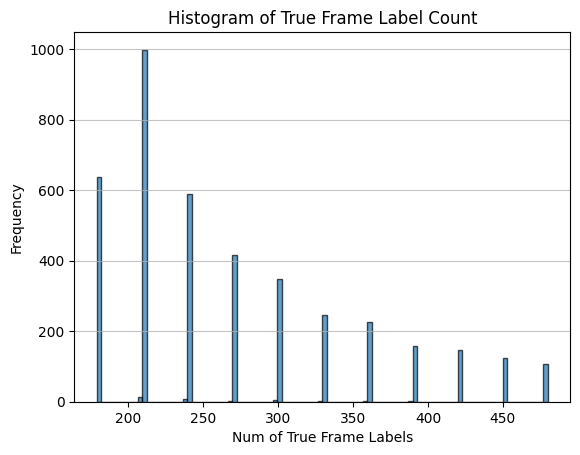

In [ ]:
print(sum(num_frames < 100))
import matplotlib.pyplot as plt
import numpy as np


# 2. Create Histogram
plt.hist(num_frames, bins=100, edgecolor='black', alpha=0.7) # Adjust alpha for transparency

# 3. Add Labels and Title
plt.xlabel("Num of True Frame Labels")
plt.ylabel("Frequency")
plt.title("Histogram of True Frame Label Count")

# 4. Display Plot
plt.grid(axis='y', alpha=0.75) # Optional: Add a grid
plt.show()

In [ ]:
print(num_frames)
bad_indices = np.where(num_frames < 150)[0]

print(f"{bad_indices=}")
print(f"{len(bad_indices)=}")

good_indices = np.delete(np.arange(len(num_frames)), bad_indices)
print(f"{len(num_frames)=}")
print(f"{good_indices=}")
print(f"{len(good_indices)=}")

[270 270 270 ... 180 180 180]
bad_indices=array([], dtype=int64)
len(bad_indices)=0
len(num_frames)=4032
good_indices=array([   0,    1,    2, ..., 4029, 4030, 4031])
len(good_indices)=4032


X: torch.Size([4032, 12437, 2]) torch.float32 cuda:1
y: torch.Size([4032, 12437]) torch.bool cuda:1
mask: torch.Size([4032, 12437]) torch.bool cuda:1
first 4 file lengths: [5117 6699 5907 6794]
first 4 file frame counts: [270 270 270 270]

sample0 (/home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw10mbit_delay20_jitter5_loss0/sample_0/video_camera1_pkts_1x_pktlen.csv) info:
sample_len=0.039893150329589844 (s)
num of frames predicted by windowing: 1.1967945098876953
actual num of frames: 10
[False False False ... False False False]
Sum of target tensor: 270
Actual number of frames: 270
Valid length of target tensor: 5117
Making sure the last boundary is True
tensor(True, device='cuda:1')
[2.49985605e-05 4.39999625e-04 1.64999999e-03 2.85999849e-03
 3.10148858e-03 6.72048517e-03 7.93048553e-03 9.14048590e-03
 1.02420524e-02 1.13808308e-02 1.25938300e-02 1.38038304e-02

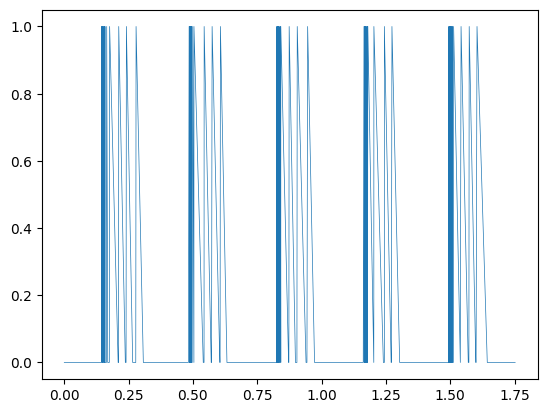

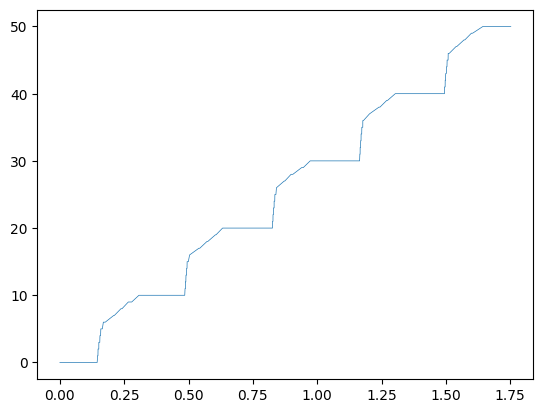

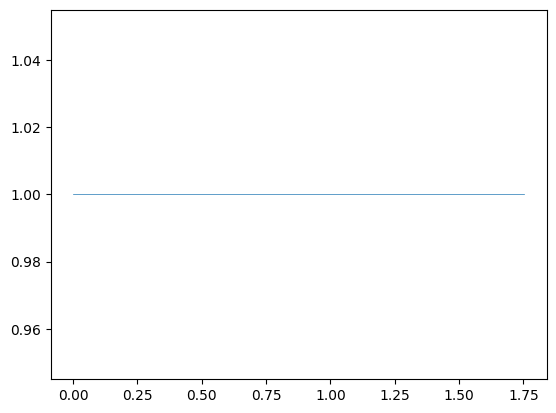

In [ ]:
print("X:", X.shape, X.dtype, X.device)     # [S, N_max, 2]
print("y:", y.shape, y.dtype, y.device)     # [S, N_max]
print("mask:", mask.shape, mask.dtype, mask.device)
print("first 4 file lengths:", lengths[:4])
print("first 4 file frame counts:", num_frames[:4])
# print("first path:", paths[0] if len(paths) else None)

print(f"\nsample0 ({paths[0]}) info:")
sample_len = X[0,:,0].max().item()
print(f"{sample_len=} (s)")
print(f"num of frames predicted by windowing: {sample_len*30}")
print(f"actual num of frames: {y[0,:num_frames[0]].sum()}")


import matplotlib.pyplot as plt
xmin = 0
xmax = 1000
# xrange = range(len(y[0,xmin:xmax]))
xrange = np.cumsum(X[0,xmin:xmax,0].cpu().numpy())
plt.figure()
plt.plot(xrange,y[0,xmin:xmax].cpu().numpy(), linewidth=0.5)
plt.figure()
plt.plot(xrange,frame_assignments[0,xmin:xmax].cpu().numpy(), linewidth=0.5)
plt.figure()
plt.plot(xrange,mask[0,xmin:xmax].cpu().numpy(), linewidth=0.5)
print(y[0,:].cpu().numpy())
print(f"Sum of target tensor: {y[0,:].sum()}")
print(f"Actual number of frames: {num_frames[0]}")
print(f"Valid length of target tensor: {lengths[0]}")
print("Making sure the last boundary is True")
print(y[0,lengths[0]-1])

print(xrange)

In [ ]:
import pandas as pd
# Extract unique values and counts
unique_vals, counts = frame_assignments[0, :].unique(return_counts=True)
# Move to CPU if on GPU
unique_vals = unique_vals.cpu().numpy()
counts = counts.cpu().numpy()
# Sort by label for readability
order = np.argsort(unique_vals)
unique_vals, counts = unique_vals[order], counts[order]
# Pretty print as a DataFrame
df = pd.DataFrame({
    "frame_id": unique_vals,
    "packet_count": counts
})
print(df.to_string(index=False))

 frame_id  packet_count
       -1          7320
        0           121
        1             2
        2             3
        3             4
        4             4
        5             5
        6             8
        7             5
        8             5
        9            10
       10           147
       11             2
       12             2
       13             3
       14             3
       15             4
       16             4
       17             3
       18             4
       19             4
       20           160
       21             2
       22             2
       23             3
       24             3
       25             4
       26             3
       27             3
       28             4
       29             4
       30           160
       31             2
       32             2
       33             3
       34             3
       35             4
       36             3
       37             3
       38             4
       39       

## Statistics of boundary packets, and non-boundary packets

In [ ]:
import torch

# lens: packet lengths; mask: valid packets; y: per-packet frame ids (0..F_i-1); pads are -1
lens = X[:, :, 1]          # [S, T]
mb   = mask                # [S, T] (True = real)
yid  = y                   # [S, T]

# Identify boundary packets: last packet of each frame (incl. last valid packet)
y_next  = torch.roll(yid, shifts=-1, dims=1)
m_next  = torch.roll(mb,  shifts=-1, dims=1)
is_boundary = mb & (~m_next | (yid != y_next))   # valid AND (next is pad OR frame id changes)
is_interior = mb & (~is_boundary)

# Collect values (mask already excludes pads)
boundary_lens = lens[is_boundary]
interior_lens = lens[is_interior]

def tstats(t: torch.Tensor):
    if t.numel() == 0:
        return {"n": 0, "mean": float("nan"), "std": float("nan"), "min": float("nan"), "max": float("nan")}
    return {
        "n":   int(t.numel()),
        "mean": float(t.mean().item()),
        "std":  float(t.std(unbiased=False).item()),
        "min":  float(t.min().item()),
        "max":  float(t.max().item()),
    }

b_stats = tstats(boundary_lens)
i_stats = tstats(interior_lens)

print("\nBoundary packets (last packet of each frame):")
print(f"  n={b_stats['n']:,}  mean={b_stats['mean']:.3f}  std={b_stats['std']:.3f}  "
      f"min={b_stats['min']:.3f}  max={b_stats['max']:.3f}")

print("\nInterior packets (all other packets within frames):")
print(f"  n={i_stats['n']:,}  mean={i_stats['mean']:.3f}  std={i_stats['std']:.3f}  "
      f"min={i_stats['min']:.3f}  max={i_stats['max']:.3f}")

print(f"\nNumber of interior lens that != 1514: {interior_lens[interior_lens!=1514].sum()}")
print(f"Proportion: {interior_lens[interior_lens!=1514].sum() / len(interior_lens)}")

print(f"\nNumber of interior lens that <= 1000: {interior_lens[interior_lens<=1000].sum()}")
print(f"Proportion: {interior_lens[interior_lens<=1000].sum() / len(interior_lens)}")

total_frames = int(num_frames.sum()) if 'num_frames' in globals() else None
if total_frames is not None:
    print(f"\nboundary count = {b_stats['n']:,} vs total frames = {total_frames:,}")

del boundary_lens
del interior_lens
del is_boundary
del is_interior
del lens
del mb
del y_next
del m_next
del yid


Boundary packets (last packet of each frame):
  n=2,170,200  mean=1142.519  std=463.011  min=57.000  max=1514.000

Interior packets (all other packets within frames):
  n=22,293,527  mean=1513.999  std=0.858  min=250.000  max=1514.000

Number of interior lens that != 1514: 15557.0
Proportion: 0.0006978258606977761

Number of interior lens that <= 1000: 9446.0
Proportion: 0.0004237104149069637

boundary count = 2,170,200 vs total frames = 1,085,122


## Normalizing the input packets

In [ ]:
# X: [S,T,2], mask: [S,T]  (True = valid)
mask3 = mask.unsqueeze(-1)                        # [S,T,1]
valid = mask3.to(X.dtype)                         # 1.0 for valid, 0.0 for pad

# --- masked mean & std per feature (over S and T) ---
cnt = valid.sum(dim=(0,1)).clamp_min(1)           # scalar count of valid tokens
sum_x  = (X * valid).sum(dim=(0,1))               # [2]
mean   = sum_x / cnt                               # [2]

sum_sq = (((X - mean) * valid) ** 2).sum(dim=(0,1))  # [2]
std    = (sum_sq / cnt).clamp_min(1e-12).sqrt()      # [2] avoid div-by-zero

# --- normalize only at valid positions ---
X_centered = (X - mean) / std                      # [S,T,2]
# keep pads as-is (or choose a fill value like 0.0 or -1.0)
X_norm = torch.where(mask3, X_centered, X)         # [S,T,2]

print(X_norm.shape)
print((X_norm * valid).mean(dim=(0,1)))

torch.Size([4032, 12437, 2])
tensor([2.0294e-08, 2.5534e-07], device='cuda:1')


In [ ]:
print(X[0,:150,:])

print(X[0,:,0].max())
print(X[0,:,0].min())

print(X[0,:,1].max())
print(X[0,:,1].min())

print(X_norm[0,:150,:])

print(X_norm[0,:,0].max())
print(X_norm[0,:,0].min())

print(X_norm[0,:,1].max())
print(X_norm[0,:,1].min())

tensor([[2.4999e-05, 1.5140e+03],
        [4.1500e-04, 1.5140e+03],
        [1.2100e-03, 1.5140e+03],
        [1.2100e-03, 1.5140e+03],
        [2.4149e-04, 1.5140e+03],
        [3.6190e-03, 1.5140e+03],
        [1.2100e-03, 1.5140e+03],
        [1.2100e-03, 1.5140e+03],
        [1.1016e-03, 1.5140e+03],
        [1.1388e-03, 1.5140e+03],
        [1.2130e-03, 1.5140e+03],
        [1.2100e-03, 1.5140e+03],
        [1.7816e-03, 1.5140e+03],
        [1.2180e-03, 1.5140e+03],
        [1.2030e-03, 1.5140e+03],
        [1.2090e-03, 1.5140e+03],
        [1.2070e-03, 1.5140e+03],
        [4.7110e-04, 1.5140e+03],
        [1.2130e-03, 1.5140e+03],
        [1.2100e-03, 1.5140e+03],
        [1.2070e-03, 1.5140e+03],
        [8.0073e-04, 1.5140e+03],
        [1.2090e-03, 1.5140e+03],
        [1.9281e-04, 1.5140e+03],
        [1.7997e-03, 1.5140e+03],
        [1.2120e-03, 1.5140e+03],
        [1.2120e-03, 1.5140e+03],
        [1.2230e-03, 1.5140e+03],
        [2.1140e-03, 1.5140e+03],
        [2.583

# Learning 

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import math

# class RelativePositionalBias(nn.Module):
#     """Simple bucketed relative bias (optional but helpful)."""
#     def __init__(self, num_buckets=32, max_dist=512, n_heads=8):
#         super().__init__()
#         self.num_buckets = num_buckets
#         self.max_dist = max_dist
#         self.n_heads = n_heads
#         self.bias = nn.Embedding(num_buckets, n_heads)

#     def _bucket(self, rel_pos):
#         # rel_pos: [T,T]
#         n = self.num_buckets
#         max_d = self.max_dist
#         rp = rel_pos.abs()
#         # half linear, half log
#         is_small = rp < n // 2
#         val_if_large = (
#             ((rp.float() / (max_d / (n - n//2))).log1p() * (n - n//2 - 1)).long()
#             .clamp(min=0, max=n - n//2 - 1) + n//2
#         )
#         buckets = torch.where(is_small, rp, val_if_large)
#         return buckets.clamp(max=n-1)

#     def forward(self, T, device):
#         pos = torch.arange(T, device=device)
#         rel = pos[None, :] - pos[:, None]  # [T,T]
#         buckets = self._bucket(rel)
#         # [T,T,H] -> [H,T,T]
#         return self.bias(buckets).permute(2, 0, 1)

class SinusoidalPositionalEncoding(nn.Module):
    """Produces [1, T, d_model] to add onto token embeddings."""
    def __init__(self, d_model: int, max_len: int = 250):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)   # [L,1]
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)   # even
        pe[:, 1::2] = torch.cos(position * div_term)   # odd
        pe = pe.unsqueeze(0)  # [1, L, d_model]
        self.register_buffer('pe', pe, persistent=False)

    def forward(self, T: int) -> torch.Tensor:
        # returns [1, T, d_model]
        return self.pe[:, :T, :]

class PacketSegformer(nn.Module):
    """
    Boundary-only Transformer with ABSOLUTE positional encoding (sinusoidal).
    Inputs: x [B,T,2] with padding as -1, plus mask [B,T] (True=real).
    Output: {'b_logit': [B,T]} boundary logits (higher => frame starts here).
    """
    def __init__(self, d_model=128, nhead=8, num_layers=4, dim_ff=256, p_drop=0.1):
        super().__init__()
        # We still build 5 per-token features inside forward:
        # [time, len, dt, logdt, pos_frac] -> project to d_model
        self.in_proj = nn.Sequential(
            nn.Linear(5, d_model),
            nn.ReLU(), nn.Dropout(p_drop)
        )
        self.pos_enc = SinusoidalPositionalEncoding(d_model)

        enc_layer = TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=p_drop, batch_first=True, norm_first=True
        )
        self.encoder = TransformerEncoder(enc_layer, num_layers=num_layers)

        self.boundary_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(d_model // 2, 1)
        )

    def _prep_inputs(self, x, mask):
        # x: [B,T,2] with -1 padding; mask: [B,T]
        B, T, _ = x.shape
        device = x.device
        x_clipped = torch.where(mask.unsqueeze(-1), x, torch.tensor(0.0, device=device))
        t = x_clipped[:, :, 0]
        dt = torch.where(mask, torch.diff(t, dim=1, prepend=t[:, :1]), torch.zeros_like(t))
        dt = dt.clamp(min=1e-9)
        logdt = dt.log()
        pos_frac = (torch.arange(T, device=device)[None, :].expand(B, T) / max(T - 1, 1)).to(x.dtype)
        feats = torch.stack([t, x_clipped[:, :, 1], dt, logdt, pos_frac], dim=-1)  # [B,T,5]
        return feats

    def forward(self, x, mask):
        """
        x: [B,T,2], mask: [B,T] (True=real)
        Returns: {'b_logit': [B,T]}
        """
        B, T, _ = x.shape
        feats = self._prep_inputs(x, mask)           # [B,T,5]
        h = self.in_proj(feats)                      # [B,T,D]

        # add absolute positional encoding
        h = h + self.pos_enc(T).to(h.dtype).to(h.device)  # broadcast [1,T,D]

        # padding mask for attention (True = mask out)
        attn_mask = ~mask
        z = self.encoder(h, src_key_padding_mask=attn_mask)

        b_logit = self.boundary_head(z).squeeze(-1)  # [B,T]
        return {"b_logit": b_logit}



In [ ]:
from torch.utils.data import Dataset
import torch

class WindowedPacketSeqDataset(Dataset):
    """
    Creates overlapping windows from (X, y, mask).

    Inputs:
      X:    [S, T, 2]  float32   (features; column 0 must be time-delta)
      y:    [S, T]     EITHER:
              - bool boundary vector (preferred; True only at end-of-frame), OR
              - int frame-ids (fallback; we will convert to end-of-frame boundary)
      mask: [S, T]     bool      (True = valid token)

    Args:
      window_size: number of tokens per window (fixed; right-padded)
      stride:      hop between consecutive window starts

    Returns per item (no btgt anymore):
      Xw: [W, 2]   float32
      yw: [W]      bool  (end-of-frame boundary; True only at last packet of a frame)
      mw: [W]      bool  (True = valid)
    """
    def __init__(self, X, y, mask, window_size=500, stride=25):
        super().__init__()
        assert X.dim() == 3 and X.size(-1) == 2, "X must be [S,T,2]"
        assert y.dim() == 2 and mask.dim() == 2 and y.shape == mask.shape == X.shape[:2]

        self.X = X
        self.y = y
        self.mask = mask
        self.W = int(window_size)
        self.stride = int(stride)

        # Determine mode: boundary-bool vs frame-id
        self._y_is_boundary_bool = (y.dtype == torch.bool)

        # Build (seq_idx, start_idx) index
        self.index = []
        S, T = y.shape
        for s in range(S):
            n = int(self.mask[s].sum().item())  # valid length for this sequence
            if n == 0:
                continue
            starts = list(range(0, n, self.stride))
            # ensure we include a last window that reaches the end
            last_start = max(0, n - self.W)
            if not starts or starts[-1] != last_start:
                starts.append(last_start)
            starts = sorted(set(starts))
            for st in starts:
                self.index.append((s, st))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        s, st = self.index[idx]
        W = self.W

        # valid tokens available from st
        n = int(self.mask[s].sum().item())
        n_win = max(0, min(W, n - st))

        # allocate window (pad with -1.0 / False)
        Xw = torch.full((W, 2), -1.0, dtype=self.X.dtype, device=self.X.device)
        mw = torch.zeros((W,), dtype=torch.bool, device=self.mask.device)
        # boundary bool window
        yw = torch.zeros((W,), dtype=torch.bool, device=self.y.device)

        if n_win > 0:
            # copy features and mask
            Xw[:n_win] = self.X[s, st:st+n_win, :]
            mw[:n_win] = True

            if self._y_is_boundary_bool:
                # y already boundary-bool (end-of-frame). Just slice it.
                yw[:n_win] = self.y[s, st:st+n_win].to(torch.bool)
            else:
                # y are frame-ids → compute end-of-frame boundary inside the window
                fa = self.y[s, st:st+n_win]  # [n_win], int
                # end-of-frame: True where frame-id changes when looking ahead
                if n_win > 1:
                    yw[:n_win-1] = (fa[:-1] != fa[1:])
                # Always mark the last valid token in the window as boundary
                # (if the frame continues beyond the window, this still marks
                # the "end of this window segment", which is the conservative choice;
                # if you prefer not to mark it unless it's true globally, you can
                # compute using global next token when available.)
                yw[n_win-1] = True

        return Xw, yw, mw


In [ ]:
# ---------- Losses ----------
def boundary_bce_loss(b_logit, b_target, mask, pos_weight=18.0):
    logits  = b_logit.masked_select(mask)
    targets = b_target.masked_select(mask).float()
    if logits.numel() == 0:
        return torch.zeros((), device=b_logit.device)
    return F.binary_cross_entropy_with_logits(
        logits, targets,
        pos_weight=(torch.as_tensor(pos_weight, device=b_logit.device))
    )

def count_loss(b_logit, b_target, mask, delta=1.0):
    p = torch.sigmoid(b_logit) * mask.float()     # [B,T]
    pred_count = p.sum(dim=1)                     # [B]
    true_count = b_target.float().mul(mask).sum(dim=1)  # [B]
    return F.smooth_l1_loss(pred_count, true_count, beta=delta)

def emd_cdf_loss(b_logit, b_target, mask, reduction='mean'):
    p = torch.sigmoid(b_logit) * mask.float()
    y = b_target.float() * mask.float()

    cdf_p = torch.cumsum(p, dim=1)
    cdf_y = torch.cumsum(y, dim=1)
    diff  = (cdf_p - cdf_y).abs() * mask.float()

    denom = mask.sum(dim=1).clamp_min(1).unsqueeze(1)
    per_seq = diff.sum(dim=1) / denom.squeeze(1)

    if reduction == 'mean':
        return per_seq.mean()
    elif reduction == 'sum':
        return per_seq.sum()
    else:
        return per_seq

def entropy_loss(b_logit, mask, lam=1e-3, eps=1e-8):
    p = torch.sigmoid(b_logit).clamp(eps, 1-eps) * mask.float()
    H = -(p*torch.log(p) + (1-p)*torch.log(1-p))
    return lam * (H.sum() / mask.sum().clamp_min(1))

def l1_prob_loss(b_logit, mask, lam=1e-4):
    p = torch.sigmoid(b_logit) * mask.float()
    return lam * p.sum() / mask.sum().clamp_min(1)

def boundary_loss_augmented(
    b_logit, b_target, mask,
    pos_weight=18.0,
    alpha_emd=0.2,
    beta_count=1.0,
    huber_delta=1.0,
    lam_spar=1e-1,
):
    bce   = boundary_bce_loss(b_logit, b_target, mask, pos_weight=pos_weight)
    # emd   = emd_cdf_loss(b_logit, b_target, mask, reduction='mean')
    emd = torch.tensor(0)
    cnt   = count_loss(b_logit, b_target, mask, delta=huber_delta)
    spar  = l1_prob_loss(b_logit, mask, lam=lam_spar)   # or entropy_loss(...)

    loss  = bce + alpha_emd * emd + beta_count * cnt + spar
    return loss, {'bce': bce.item(), 'emd': emd.item(), 'count': cnt.item(), 'sparsity': spar.item()}

# ---------- Output Metrics ----------
@torch.no_grad()
def boundary_f1(b_logit, b_target, mask, thr=0.3, eps=1e-8):
    prob = torch.sigmoid(b_logit)
    pred = (prob > thr) & mask
    tgt  = b_target & mask

    tp = (pred & tgt).sum().float()
    fp = (pred & ~tgt).sum().float()
    fn = (~pred & tgt).sum().float()

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    acc       = ((pred == tgt) & mask).sum().float() / mask.sum().clamp(min=1)
    return f1.item(), precision.item(), recall.item(), acc.item()

@torch.no_grad()
def batch_boundary_stats(b_logit, b_target, mask, xb, thr=0.3):
    prob = torch.sigmoid(b_logit)
    pred = (prob > thr) & mask
    true = b_target & mask

    pred_count = int(pred.sum().item())
    true_count = int(true.sum().item())

    # Optional: distance calc is disabled to keep it fast
    sum_min_dists, n_preds_used = 0.0, 0
    return pred_count, true_count, sum_min_dists, n_preds_used


In [ ]:
# =================== Hyperparams ===================
D_MODEL   = 16
N_HEAD    = 1
N_LAYERS  = 4
FF_DIM    = 16
DROP      = 0.1

# Loss regularization coefficients
BCE_POS_WT  = 18.0
EMD_ALPHA   = 0.2
COUNT_BETA  = 1.0

LR        = 3.5e-4
EPOCHS    = 100
BATCH_SZ  = 48000


device = X_norm.device  # use same device as your tensors
model = PacketSegformer(
    d_model=D_MODEL, nhead=N_HEAD, num_layers=N_LAYERS,
    dim_ff=FF_DIM, p_drop=DROP
).to(device)
print(model)

# =================== Dataset Setup ===================
from torch.utils.data import random_split
from torch.utils.data import DataLoader
WINDOW_SIZE = 250
STRIDE = 25

# win_ds = WindowedPacketSeqDataset(X, y, mask, window_size=WINDOW_SIZE, stride=STRIDE)

# IZ: Exclude the indices that don't have RTP data (hence no valid y) from those used in training the separation model
# win_ds = WindowedPacketSeqDataset(X[good_indices,:,:], y[good_indices,:], mask[good_indices,:], window_size=WINDOW_SIZE, stride=STRIDE)
# IZ: Use normalized packet and timing data
win_ds = WindowedPacketSeqDataset(X_norm[good_indices,:,:], y[good_indices,:], mask[good_indices,:], window_size=WINDOW_SIZE, stride=STRIDE)
n_total = len(win_ds)
n_train = int(0.9 * n_total)
n_test  = n_total - n_train

train_ds, test_ds = random_split(win_ds, [n_train, n_test], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=BATCH_SZ, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SZ, shuffle=False, drop_last=False)


def trim_to_active(xb, yb, mb):
    lengths = mb.sum(dim=1)
    true_T = int(lengths.max().item())
    true_T = max(true_T, 1)
    return xb[:, :true_T, :], yb[:, :true_T], mb[:, :true_T]

# =================== Running the Model ===================

opt = torch.optim.AdamW(model.parameters(), lr=LR)

def run_epoch(loader, train_mode=True, thr=0.3):
    model.train(mode=train_mode)

    tot_loss = tot_bce = tot_emd = tot_cnt = tot_spar = 0.0
    n_batches = 0

    all_f1, all_acc = [], []
    total_pred_count = 0
    total_true_count = 0
    total_dist_sum   = 0.0
    total_dist_n     = 0

    for batch in loader:
        if (n_batches % 20 == 0):
            print(f"      {n_batches=}/{len(loader)}")

        # Dataset now returns 3 items
        xb, yb, mb = batch
        xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
        xb, yb, mb = trim_to_active(xb, yb, mb)

        with torch.set_grad_enabled(train_mode):
            out = model(xb, mb)                 # {'b_logit': [B,W]}
            b_logit = out["b_logit"]

            # Augmented loss components — yb is the boundary target (bool)
            loss, parts = boundary_loss_augmented(
                b_logit, yb, mb,
                pos_weight=BCE_POS_WT,
                alpha_emd=EMD_ALPHA,
                beta_count=COUNT_BETA,
            )

            if train_mode:
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

        # Component-wise losses
        tot_loss += float(loss.detach().item())
        tot_bce  += parts['bce']
        tot_emd  += parts['emd']
        tot_cnt  += parts['count']
        tot_spar += parts['sparsity']
        n_batches += 1

        # Token-wise metrics (F1/Acc) on window
        f1, prec, rec, acc = boundary_f1(b_logit.detach(), yb, mb, thr=thr)
        all_f1.append(f1); all_acc.append(acc)

        # Counts & distance (seconds) from preds to nearest true (distance disabled)
        pc, tc, dist_sum, dist_n = batch_boundary_stats(b_logit.detach(), yb, mb, xb, thr=thr)
        total_pred_count += pc
        total_true_count += tc
        total_dist_sum   += dist_sum
        total_dist_n     += dist_n

    avg_dist = (total_dist_sum / total_dist_n) if total_dist_n > 0 else float('nan')

    return {
        "loss": tot_loss / max(1, n_batches),
        "bce":  tot_bce  / max(1, n_batches),
        "emd":  tot_emd  / max(1, n_batches),
        "sparsity":  tot_spar  / max(1, n_batches),
        "count":tot_cnt  / max(1, n_batches),
        "f1":   float(np.mean(all_f1)) if all_f1 else 0.0,
        "acc":  float(np.mean(all_acc)) if all_acc else 0.0,
        "pred_boundaries": int(total_pred_count),
        "true_boundaries": int(total_true_count),
        "avg_pred_to_true_dist_sec": float(avg_dist),
    }


PacketSegformer(
  (in_proj): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (pos_enc): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (linear1): Linear(in_features=16, out_features=16, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=16, out_features=16, bias=True)
        (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (boundary_head): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): 

/home/gaofeng/miniconda3/envs/IoBT-genesis/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [ ]:
from pathlib import Path
from datetime import datetime
import json

def save_run_config(ckpt_path: str | Path,
                    d_model: int, n_head: int, n_layers: int, ff_dim: int, drop: float,
                    bce_pos_wt: float, emd_alpha: float, count_beta: float,
                    lr: float, epochs: int, batch_sz: int,
                    window_size: int, stride: int,
                    notes: str | None = None) -> tuple[Path, Path]:
    """
    Writes a text and JSON config next to the checkpoint file.
    Returns: (txt_path, json_path)
    """
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    cfg = {
        "D_MODEL": d_model,
        "N_HEAD": n_head,
        "N_LAYERS": n_layers,
        "FF_DIM": ff_dim,
        "DROP": drop,
        "BCE_POS_WT": bce_pos_wt,
        "EMD_ALPHA": emd_alpha,
        "COUNT_BETA": count_beta,
        "LR": lr,
        "EPOCHS": epochs,
        "BATCH_SZ": batch_sz,
        "WINDOW_SIZE": window_size,
        "STRIDE": stride,
        "checkpoint_file": str(ckpt_path),
        "saved_at": datetime.now().isoformat(timespec="seconds"),
    }
    if notes:
        cfg["notes"] = notes

    # Paths (e.g., best_packetsegformer.pkl -> best_packetsegformer.config.txt/.json)
    txt_path  = ckpt_path.with_suffix(".config.txt")

    # Write pretty text (key=value)
    lines = [
        f"# Config for: {ckpt_path.name}",
        f"# Saved at:  {cfg['saved_at']}",
        ""
    ]
    for k in ["D_MODEL","N_HEAD","N_LAYERS","FF_DIM","DROP",
              "BCE_POS_WT","EMD_ALPHA","COUNT_BETA",
              "LR","EPOCHS","BATCH_SZ","WINDOW_SIZE","STRIDE"]:
        lines.append(f"{k}={cfg[k]}")
    if notes:
        lines.append(f"NOTES={notes}")

    txt_path.write_text("\n".join(lines) + "\n")

    print(f"[save_run_config] wrote:\n  {txt_path}")
    return txt_path


# ==== Example usage ====
# Assuming you already have CKPT_PATH defined (e.g., "checkpoints/best_packetsegformer.pkl")
_ = save_run_config(
    ckpt_path=MODEL_PATH,
    d_model=D_MODEL, n_head=N_HEAD, n_layers=N_LAYERS, ff_dim=FF_DIM, drop=DROP,
    bce_pos_wt=BCE_POS_WT, emd_alpha=EMD_ALPHA, count_beta=COUNT_BETA,
    lr=LR, epochs=EPOCHS, batch_sz=BATCH_SZ,
    window_size=WINDOW_SIZE, stride=STRIDE,
    notes=None  # or "run with marker-based labels"
)

[save_run_config] wrote:
  /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw10mbit_delay20_jitter5_loss0/packet_grouping_model_weights/best_packetsegformer.config.txt


In [ ]:
import os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

best_test_acc = -1.0
# best_test_loss = 1e8
train_acc_hist, test_acc_hist = [], []
train_loss_hist, test_loss_hist = [], []

epochs_stop_threshold = 10
epochs_since_last_best = 0

for epoch in range(1, EPOCHS + 1):
    print(f"EPOCH [{epoch:03d}/{EPOCHS}]")
    print("   Starting Train Epoch")
    tr = run_epoch(train_loader, train_mode=True)
    print("   Starting Test Epoch")
    te = run_epoch(test_loader,  train_mode=False)

    train_acc_hist.append(tr["acc"]);  test_acc_hist.append(te["acc"])
    train_loss_hist.append(tr["loss"]); test_loss_hist.append(te["loss"])

    print(
        f"   Train: loss={tr['loss']:.4f} (bce={tr['bce']:.4f}, emd={tr['emd']:.4f}, cnt={tr['count']:.4f}) "
        f"F1={tr['f1']:.3f} Acc={tr['acc']:.3f} "
        f"| #pred={tr['pred_boundaries']} vs #true={tr['true_boundaries']} "
        f"| sparsity={tr['sparsity']:.4f}\n"
        f"   Test : loss={te['loss']:.4f} (bce={te['bce']:.4f}, emd={te['emd']:.4f}, cnt={te['count']:.4f}) "
        f"F1={te['f1']:.3f} Acc={te['acc']:.3f} "
        f"| #pred={te['pred_boundaries']} vs #true={te['true_boundaries']} "
        f"| sparsity={te['sparsity']:.4f}"
    )

    if te["acc"] > best_test_acc:
        best_test_acc = te["acc"]
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"      Saved new best checkpoint to {MODEL_PATH} (test Acc={best_test_acc:.4f})")
        epochs_since_last_best = 0
    else:
        epochs_since_last_best += 1
    print()

    if epochs_since_last_best >= epochs_stop_threshold:
        print(f"It has been {epochs_stop_threshold} epochs since setting a new best accuracy, stopping training")
        break

EPOCH [001/100]
   Starting Train Epoch
      n_batches=0/19
   Starting Test Epoch
      n_batches=0/3
   Train: loss=120.6365 (bce=1.2332, emd=0.0000, cnt=119.3499) F1=0.086 Acc=0.047 | #pred=216476236 vs #true=9711141 | sparsity=0.0534
   Test : loss=111.8019 (bce=1.1931, emd=0.0000, cnt=110.5589) F1=0.086 Acc=0.047 | #pred=24027408 vs #true=1079029 | sparsity=0.0499
      Saved new best checkpoint to /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw10mbit_delay20_jitter5_loss0/packet_grouping_model_weights/best_packetsegformer.pkl (test Acc=0.0474)

EPOCH [002/100]
   Starting Train Epoch
      n_batches=0/19
   Starting Test Epoch
      n_batches=0/3
   Train: loss=110.6408 (bce=1.2039, emd=0.0000, cnt=109.3875) F1=0.086 Acc=0.050 | #pred=215893576 vs #true=9711141 | sparsity=0.0493
   Test : loss=106.7101 (bce=1.2030, emd=0.0000, cnt=105.4593) F1=0.086 Acc=0.052 | #p

# Outputs and Plotting

In [ ]:
RESULTS_ROOT = Path(f"/home/gaofeng/zanoria/grayassets_datasets/{seed_identifier}/{carla_run_identifier}/results/{network_configuration}/stage1")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

In [ ]:
import pandas as pd
from pathlib import Path
from datetime import datetime

# Build a tidy DataFrame
epochs = list(range(1, len(train_acc_hist) + 1))
hist_df = pd.DataFrame({
    "epoch": epochs,
    "train_acc": train_acc_hist,
    "test_acc":  test_acc_hist,
    "train_loss": train_loss_hist,
    "test_loss":  test_loss_hist,
})

# Use dataset/model identifiers if available; otherwise fall back to timestamped names
csv_path = RESULTS_ROOT / "grouping_training_history.csv"

hist_df.to_csv(csv_path, index=False)

print(f"Saved metrics to:- {csv_path}")

Saved metrics to:- /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/results/bw10mbit_delay20_jitter5_loss0/stage1/grouping_training_history.csv


Saved: /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/results/bw10mbit_delay20_jitter5_loss0/stage1/accuracy_over_epochs.png


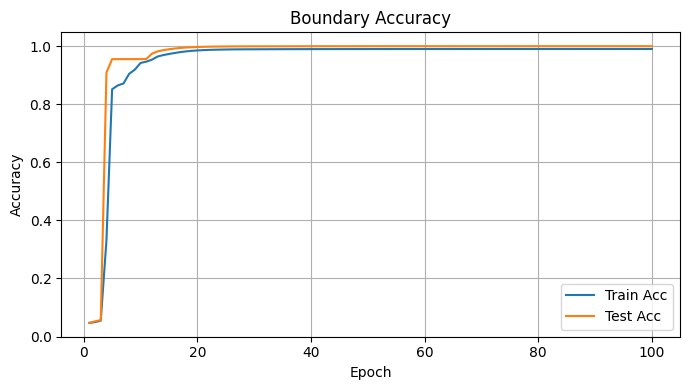

Saved: /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/results/bw10mbit_delay20_jitter5_loss0/stage1/loss_over_epochs.png


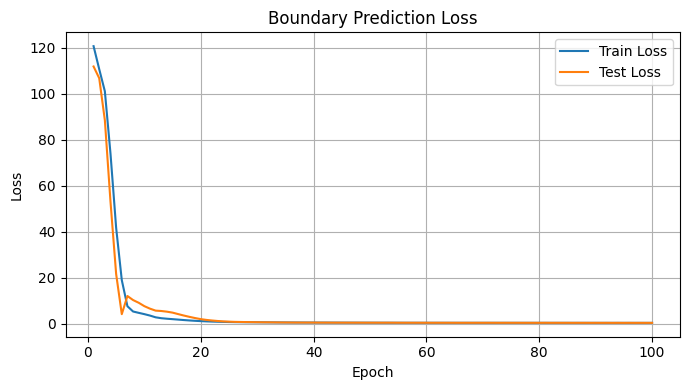

In [ ]:
# ----- Plot train/test accuracy over epochs -----
xrange = range(1, len(train_acc_hist)+1)

def save_and_show(fig, basename: str):
    png_path = RESULTS_ROOT / f"{basename}.png"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {png_path}")
    plt.show()
    plt.close(fig)

fig1 = plt.figure(figsize=(7,4))
plt.plot(xrange, train_acc_hist, label="Train Acc")
plt.plot(xrange, test_acc_hist,  label="Test Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Boundary Accuracy")
plt.grid(True); plt.legend(); plt.tight_layout()
save_and_show(fig1, "accuracy_over_epochs")

fig2 = plt.figure(figsize=(7,4))
plt.plot(xrange, train_loss_hist, label="Train Loss")
plt.plot(xrange, test_loss_hist,  label="Test Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Boundary Prediction Loss")
plt.grid(True); plt.legend(); plt.tight_layout()
save_and_show(fig2, "loss_over_epochs")

# Prediction Plots

Loaded weights from /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw10mbit_delay20_jitter5_loss0/packet_grouping_model_weights/best_packetsegformer.pkl

=== First plotted window: timestamp vs TRUE/PRED boundary ===
 idx    time_abs[s]      TRUE   PRED
   0       1.670063        0      0
   1       1.671273        0      0
   2       1.672483        0      0
   3       1.673703        0      0
   4       1.674906        0      0
   5       1.676116        0      0
   6       1.677327        0      0
   7       1.678539        0      0
   8       1.679750        0      0
   9       1.679893        0      0
  10       1.681114        0      0
  11       1.682588        0      0
  12       1.682948        0      0
  13       1.684150        0      0
  14       1.684647        0      0
  15       1.686647        0      0
  16       1.687848        0      0
  17       1.690129 

/home/gaofeng/miniconda3/envs/IoBT-genesis/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Saved: /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/results/bw10mbit_delay20_jitter5_loss0/stage1/boundary_val_plots.png


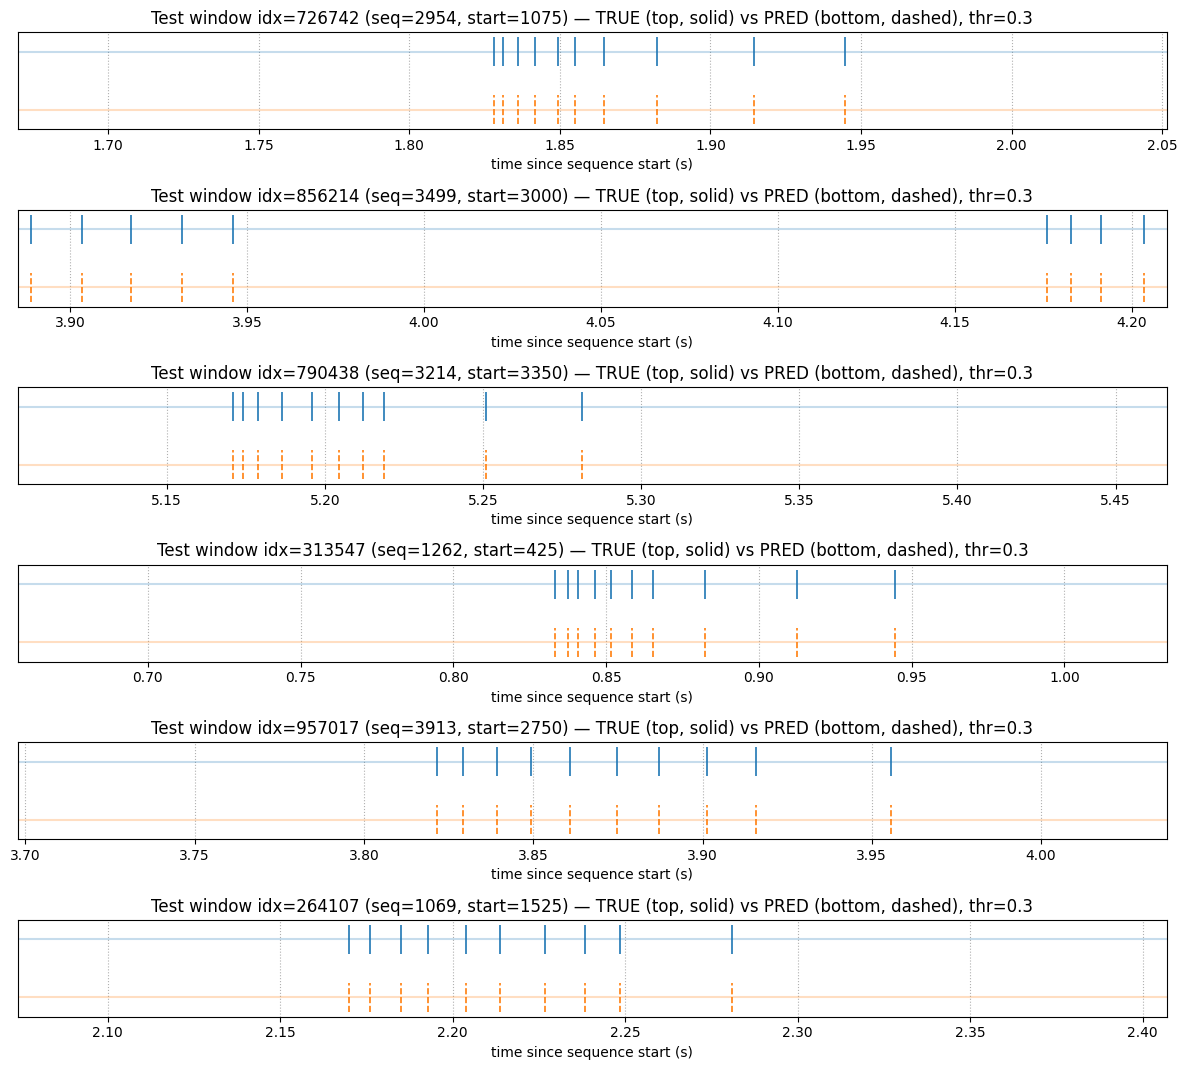


Boundary count summary (these windows):
  win ds_idx=726742 (seq=2954, start=1075): Predicted=10 | True=10 | Δ=+0
  win ds_idx=856214 (seq=3499, start=3000): Predicted=9 | True=9 | Δ=+0
  win ds_idx=790438 (seq=3214, start=3350): Predicted=10 | True=10 | Δ=+0
  win ds_idx=313547 (seq=1262, start=425): Predicted=10 | True=10 | Δ=+0
  win ds_idx=957017 (seq=3913, start=2750): Predicted=10 | True=10 | Δ=+0
  win ds_idx=264107 (seq=1069, start=1525): Predicted=10 | True=10 | Δ=+0


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ----- Reload best checkpoint -----
loaded_model = PacketSegformer(
    d_model=D_MODEL, nhead=N_HEAD, num_layers=N_LAYERS,
    dim_ff=FF_DIM, p_drop=DROP
).to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
print(f"Loaded weights from {MODEL_PATH}")

@torch.no_grad()
def predict_window(model, Xw, Mw, thr=0.5):
    """
    Xw: [W,2], Mw: [W]  (bool)
    Returns: pred_mask [W] (bool), prob [W] (float)
    """
    out = model(Xw.unsqueeze(0), Mw.unsqueeze(0))          # {'b_logit':[1,W]}
    b_logit = out["b_logit"].squeeze(0)                    # [W]
    prob = torch.sigmoid(b_logit)
    pred = (prob > thr) & Mw
    return pred, prob

def reconstruct_abs_times_for_window(win_ds, X_norm, base_mask, ds_idx):
    """
    Build absolute timestamps (relative to sequence start) for a window item
    by mapping (seq_id, start_idx) and cumsumming deltas along the full sequence.
    """
    s, st = win_ds.index[ds_idx]
    n_valid = int(base_mask[s].sum().item())
    full_cum = torch.cumsum(X_norm[s, :n_valid, 0], dim=0)      # [n_valid], seconds from sequence start
    W = win_ds.W
    n_win = max(0, min(W, n_valid - st))
    t_abs = full_cum[st:st+n_win]                               # [n_win]
    return s, st, n_win, t_abs

def table_for_first_window(t_abs, true_b, pred_b, max_rows=60):
    """
    Pretty-print (time_abs, TRUE, PRED) for quick validation.
    """
    n = t_abs.numel()
    n_show = min(n, max_rows)
    print("\n=== First plotted window: timestamp vs TRUE/PRED boundary ===")
    print(" idx    time_abs[s]      TRUE   PRED")
    for i in range(n_show):
        t = float(t_abs[i])
        tb = bool(true_b[i])
        pb = bool(pred_b[i])
        print(f"{i:4d}   {t:12.6f}    {int(tb):5d}  {int(pb):5d}")
    if n > n_show:
        print(f"... ({n-n_show} more rows)")

@torch.no_grad()
def plot_from_test_subset(model, win_ds, test_subset, X_norm, X_unnorm, base_y, base_mask,
                          device, num_windows=4, thr=0.5):
    """
    Plot first `num_windows` windows from the test subset.
      - TRUE boundaries come from windowed dataset's y (bool, end-of-frame).
      - PRED boundaries are model predictions thresholded at `thr`.
      - X[...,0] are inter-arrival deltas; we cumsum to absolute time.
    """
    # Gather dataset indices that the Subset points at
    if not hasattr(test_subset, "indices"):
        raise ValueError("`test_subset` must be a torch.utils.data.Subset (from random_split).")
    ds_indices = test_subset.indices[:num_windows]
    if len(ds_indices) == 0:
        print("Test subset is empty.")
        return

    fig, axes = plt.subplots(len(ds_indices), 1, figsize=(12, 1.8*len(ds_indices)), sharex=False)
    if len(ds_indices) == 1:
        axes = [axes]

    first_window_printed = False

    for r_i, ds_idx in enumerate(ds_indices):
        # Pull the exact window item (no batching): WindowedPacketSeqDataset returns (Xw, yw, mw)
        Xw, Yw, Mw = win_ds[ds_idx]          # shapes: [W,2], [W], [W]
        # Enforce expected dtypes
        Yw = Yw.bool()
        Mw = Mw.bool()

        # Send to device
        Xw = Xw.to(device); Yw = Yw.to(device); Mw = Mw.to(device)

        # Predict on this window
        pred_mask, prob = predict_window(model, Xw, Mw, thr=thr)  # [W], [W]

        # Reconstruct absolute time for this window (relative to whole sequence start)
        s, st, n_win, t_abs = reconstruct_abs_times_for_window(win_ds, X_unnorm, base_mask, ds_idx)
        t_abs = t_abs.to(device)

        # Slice TRUE/PRED to the valid part of this window
        true_b = Yw[:n_win]
        pred_b = pred_mask[:n_win]

        # Print a compact table for the first plotted window
        if not first_window_printed:
            table_for_first_window(t_abs, true_b, pred_b, max_rows=500)
            first_window_printed = True

        # ---- Plot: Two parallel bands of vlines (TRUE top, PRED bottom) ----
        ax = axes[r_i]
        if n_win == 0:
            ax.set_visible(False)
            continue

        t_true = t_abs[true_b].detach().cpu().tolist()
        t_pred = t_abs[pred_b].detach().cpu().tolist()

        # Bands: TRUE (top), PRED (bottom)
        t0 = float(t_abs.min().item()) if t_abs.numel() else 0.0
        t1 = float(t_abs.max().item()) if t_abs.numel() else 1.0
        ax.hlines(0.8, t0, t1, colors='tab:blue', alpha=0.25)
        ax.hlines(0.2, t0, t1, colors='tab:orange', alpha=0.25)

        # TRUE marks (top)
        for tt in t_true:
            ax.vlines(tt, 0.65, 0.95, colors="tab:blue", linewidth=1.2,
                      label="True" if r_i == 0 else None)
        # PRED marks (bottom)
        for tp in t_pred:
            ax.vlines(tp, 0.05, 0.35, colors="tab:orange", linewidth=1.2, linestyles='dashed',
                      label="Pred" if r_i == 0 else None)

        ax.set_ylim(0.0, 1.0)
        ax.set_xlim(t0, t1)
        ax.set_yticks([])
        ax.set_xlabel("time since sequence start (s)")
        ax.set_title(f"Test window idx={ds_idx} (seq={s}, start={st}) — TRUE (top, solid) vs PRED (bottom, dashed), thr={thr}")
        ax.grid(True, axis='x', linestyle=':')

    plt.tight_layout()
    
    save_and_show(fig, "boundary_val_plots")

    


    # ----- Boundary count summary for these windows -----
    print("\nBoundary count summary (these windows):")
    for ds_idx in ds_indices:
        # Reload quickly to count with exact same slices
        _, Yw, Mw = win_ds[ds_idx]
        Yw = Yw.bool(); Mw = Mw.bool()
        Xw = win_ds[ds_idx][0].to(device)
        Mw_d = Mw.to(device)

        pred_mask, _ = predict_window(model, Xw.to(device), Mw_d, thr=thr)

        s, st, n_win, _ = reconstruct_abs_times_for_window(win_ds, X_unnorm, base_mask, ds_idx)
        pred_n = int(pred_mask[:n_win].sum().item())
        true_n = int(Yw[:n_win].sum().item())
        print(f"  win ds_idx={ds_idx} (seq={s}, start={st}): Predicted={pred_n} | True={true_n} | Δ={pred_n - true_n:+d}")

# ---- run it on the first few windows of the test subset ----
plot_from_test_subset(
    model=loaded_model,
    win_ds=win_ds,
    test_subset=test_ds,       # torch.utils.data.Subset from random_split
    X_norm=X_norm, X_unnorm=X, base_y=y, base_mask=mask,
    device=device,
    num_windows=6,
    thr=0.3
)


## Reconstructed framesizes comparison

Saved: /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/results/bw10mbit_delay20_jitter5_loss0/stage1/reconstructed_framesizes_val_plots.png


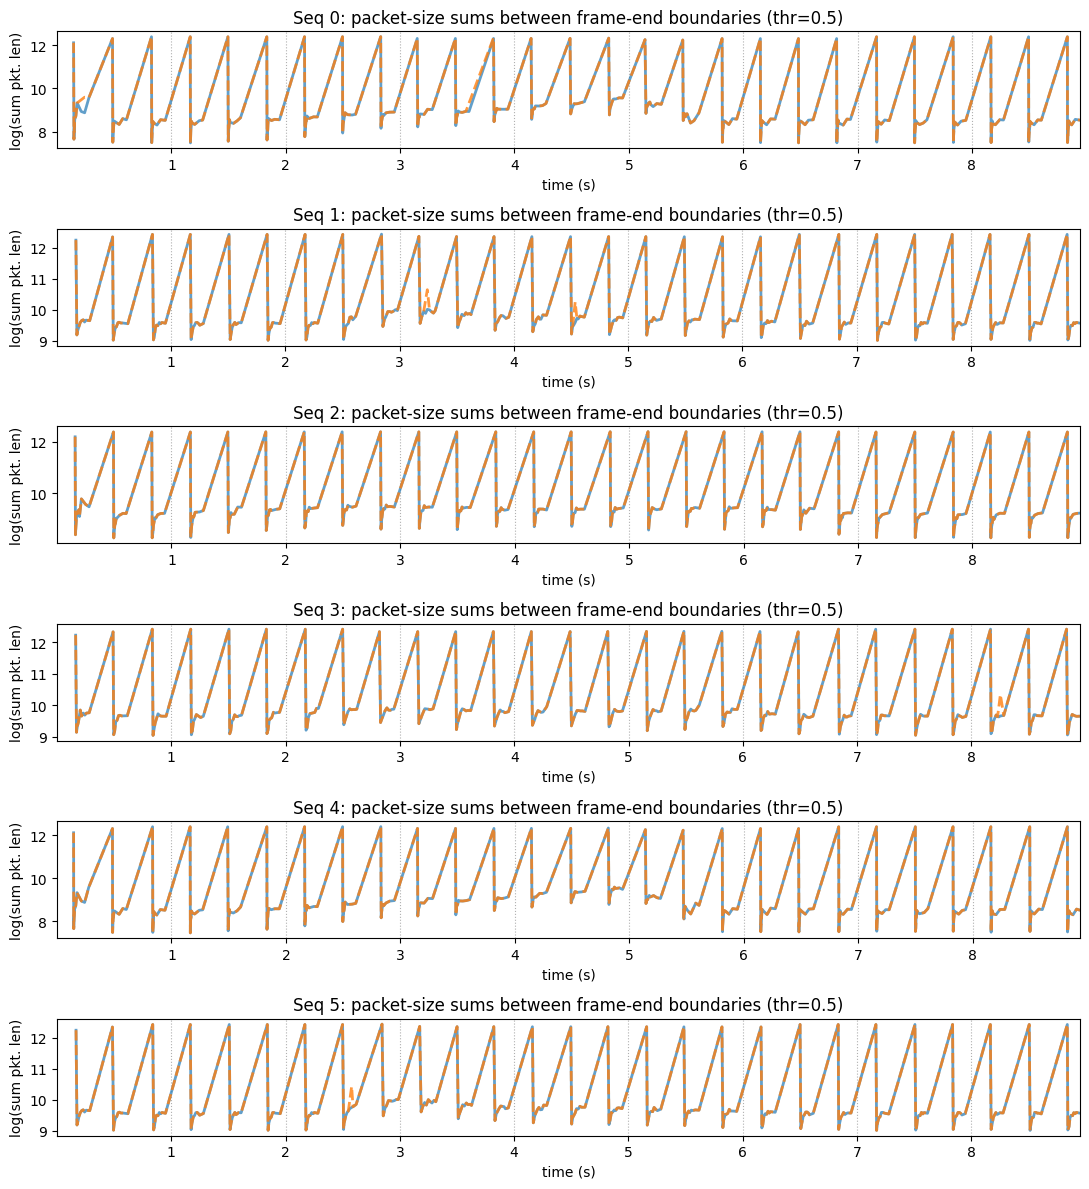


=== Boundary count summary (end-of-frame) ===
Seq 0: Predicted=268  |  True=270  |  Δ=-2
Seq 1: Predicted=268  |  True=270  |  Δ=-2
Seq 2: Predicted=269  |  True=270  |  Δ=-1
Seq 3: Predicted=269  |  True=270  |  Δ=-1
Seq 4: Predicted=270  |  True=270  |  Δ=+0
Seq 5: Predicted=269  |  True=270  |  Δ=-1


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helpers ----------
@torch.no_grad()
def predict_full_boundaries(model, X_seq, M_seq, thresh=0.5, section_len=2000):
    """
    Predict boundaries for a single full sequence by slicing into non-overlapping
    sections (to keep attention sizes manageable).

    X_seq: [T,2]   (X[...,0] are time deltas)
    M_seq: [T]     (bool)
    Returns:
      pred_mask: [T] bool (False on pads)
      prob:      [T] float (0 on pads)
    """
    T = X_seq.shape[0]
    pred_mask = torch.zeros(T, dtype=torch.bool, device=X_seq.device)
    prob_out  = torch.zeros(T, dtype=X_seq.dtype, device=X_seq.device)

    T_valid = int(M_seq.sum().item())
    if T_valid == 0:
        return pred_mask, prob_out

    start = 0
    while start < T_valid:
        end = min(start + section_len, T_valid)
        X_chunk = X_seq[start:end].unsqueeze(0)        # [1,L,2]
        M_chunk = M_seq[start:end].unsqueeze(0)        # [1,L]

        out = model(X_chunk, M_chunk)                  # {'b_logit':[1,L]}
        prob = torch.sigmoid(out["b_logit"]).squeeze(0)  # [L]
        pred = (prob > thresh) & M_chunk.squeeze(0)

        pred_mask[start:end] = pred
        prob_out[start:end]  = prob
        start = end

    # ensure pads are False/0
    if T_valid < T:
        pred_mask[T_valid:] = False
        prob_out[T_valid:]  = 0.0
    return pred_mask, prob_out

@torch.no_grad()
def predict_full_boundaries_sliding(
    model,
    X_seq,
    M_seq,
    thresh: float = 0.5,
    window_size: int = 250,
    stride: int = 50,
):
    """
    Sliding-window boundary prediction with averaging over overlapping windows.

    Args:
      model: transformer model
      X_seq: [T, 2] input sequence (X[...,0] are time deltas)
      M_seq: [T] mask (True=valid)
      thresh: decision threshold on averaged probs
      window_size: size of each transformer window
      stride: sliding stride (overlap = window_size - stride)

    Returns:
      pred_mask: [T] bool mask (boundary if avg_prob > thresh)
      avg_prob: [T] averaged probabilities (0 padded)
    """
    T = X_seq.shape[0]
    device = X_seq.device
    T_valid = int(M_seq.sum().item())
    if T_valid == 0:
        return torch.zeros(T, dtype=torch.bool, device=device), torch.zeros(T, dtype=X_seq.dtype, device=device)

    # --- Initialize accumulators ---
    sum_probs = torch.zeros(T_valid, dtype=X_seq.dtype, device=device)
    sum_counts = torch.zeros(T_valid, dtype=X_seq.dtype, device=device)

    # --- Sliding windows ---
    starts = list(range(0, max(1, T_valid - window_size + 1), stride))
    if starts[-1] + window_size < T_valid:
        starts.append(T_valid - window_size)  # include last partial window

    for start in starts:
        end = min(start + window_size, T_valid)
        X_chunk = X_seq[start:end].unsqueeze(0)
        M_chunk = M_seq[start:end].unsqueeze(0)

        out = model(X_chunk, M_chunk)
        prob = torch.sigmoid(out["b_logit"]).squeeze(0)  # [L]
        L = prob.shape[0]

        sum_probs[start:start+L] += prob
        sum_counts[start:start+L] += 1.0

    # --- Average overlapping probabilities ---
    avg_prob = sum_probs / sum_counts.clamp_min(1.0)
    avg_prob_full = torch.zeros(T, dtype=X_seq.dtype, device=device)
    avg_prob_full[:T_valid] = avg_prob

    # --- Threshold to get binary boundary mask ---
    pred_mask = (avg_prob_full > thresh) & M_seq

    return pred_mask, avg_prob_full

def aggregate_packet_sizes_end(packet_times_abs, packet_sizes, boundary_mask_end):
    """
    Boundaries mark the END of a frame:
      first end e0 sums [0..e0], next end e1 sums [e0+1..e1], ...
    Returns (times_at_boundary, sum_of_sizes_in_segment).
    """
    # 1D CPU
    packet_times_abs = packet_times_abs.detach().cpu()
    packet_sizes     = packet_sizes.detach().cpu()
    boundary_mask_end = boundary_mask_end.detach().cpu()

    end_idxs = torch.nonzero(boundary_mask_end, as_tuple=False).flatten().tolist()
    if not end_idxs:
        return np.array([]), np.array([])

    sums, times = [], []
    start = 0
    for e in end_idxs:
        if e >= start:
            seg_sum = packet_sizes[start:e+1].sum().item()
            seg_t   = float(packet_times_abs[e].item())  # time at end of frame
            sums.append(seg_sum)
            times.append(seg_t)
        start = e + 1
    return np.array(times), np.array(sums)

# ---------- Plot using full tensors X, y, mask ----------
@torch.no_grad()
def plot_packet_size_sums_full(
    model,
    X_norm, X_unnorm,
    y, mask,
    device,
    seq_indices=None,           # list of sequence ids to plot; default = first few
    num_rows=6,
    thresh=0.5,
    section_len=250
):
    """
    - Uses X[...,0] (time deltas) -> cumsum to absolute time per sequence.
    - Uses y as the TRUE boundary-at-frame-end mask.
    - Runs model to get predicted boundary mask per sequence.
    - Plots log(1 + sum bytes) per frame for TRUE vs PRED.
    """
    S = X_norm.shape[0]
    if seq_indices is None:
        seq_indices = list(range(min(num_rows, S)))
    else:
        seq_indices = seq_indices[:num_rows]

    fig, axes = plt.subplots(len(seq_indices), 1, figsize=(11, 2*len(seq_indices)), sharex=False)
    if len(seq_indices) == 1:
        axes = [axes]

    for ax, s in zip(axes, seq_indices):
        M_s = mask[s]            # [T]
        if not bool(M_s.any()):
            ax.set_visible(False)
            continue

        # Build absolute time from deltas
        t_abs = torch.cumsum(X_unnorm[s, M_s, 0], dim=0)   # [Tv]
        sizes = X_unnorm[s, M_s, 1]                        # [Tv]
        true_b = y[s, M_s]                          # [Tv]  (True marks end-of-frame)

        # Predict on full sequence
        pred_b_full, _ = predict_full_boundaries(
            model, X_norm[s], mask[s], thresh=thresh, section_len=section_len
        )
        pred_b = pred_b_full[M_s]                   # [Tv]

        # Aggregate sums per frame by TRUE and by PRED
        t_true, sum_true = aggregate_packet_sizes_end(t_abs, sizes, true_b)
        t_pred, sum_pred = aggregate_packet_sizes_end(t_abs, sizes, pred_b)

        if len(sum_true) > 0:
            ax.plot(t_true, np.log1p(sum_true), label="True aggregation", lw=2, alpha=0.7)
        if len(sum_pred) > 0:
            ax.plot(t_pred, np.log1p(sum_pred), label="Pred aggregation", lw=2, linestyle="--", alpha=0.8)

        # Axis cosmetics
        ax.set_ylabel("log(sum pkt. len)")
        ax.set_xlabel("time (s)")
        if t_abs.numel() > 0:
            ax.set_xlim(float(t_abs.min().item()), float(t_abs.max().item()))
        ax.set_title(f"Seq {s}: packet-size sums between frame-end boundaries (thr={thresh})")
        ax.grid(True, axis='x', linestyle=':')
        # ax.legend()

    plt.tight_layout()
    save_and_show(fig, "reconstructed_framesizes_val_plots")

    # Boundary counts summary
    print("\n=== Boundary count summary (end-of-frame) ===")
    for s in seq_indices:
        # pred_b_full, _ = predict_full_boundaries(model, X[s], mask[s], thresh=thresh, section_len=section_len)
        pred_b_full, _ = predict_full_boundaries_sliding(
            model, X_norm[s], mask[s],
            thresh=thresh,
            window_size=section_len,  # same as before, just renamed meaning
            stride=25                 # or any stride you want (smaller = smoother averaging)
        )
        pred_n = int((pred_b_full & mask[s]).sum().item())
        true_n = int((y[s] & mask[s]).sum().item())
        print(f"Seq {s}: Predicted={pred_n}  |  True={true_n}  |  Δ={pred_n - true_n:+d}")

# --------- Run ----------
# Make sure the loaded model is on the right device
loaded_model.to(device).eval()

# Example: plot the first few sequences
plot_packet_size_sums_full(
    model=loaded_model,
    X_norm=X_norm, X_unnorm=X,
    y=y, mask=mask,
    device=device,
    seq_indices=None,   # or pass explicit list, e.g., [0,1,2]
    num_rows=6,
    thresh=0.5,
    section_len=250
)


ASSUME KNOWLEDGE OF THE CODEC (I-FRAME, P-FRAME)

ASSUME KNOWLEDGE OF THE FRAMERATE

# Produce the framesize tensor from the model

In [ ]:
[print(path) for path in paths[:5]]

/home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw10mbit_delay20_jitter5_loss0/sample_0/video_camera1_pkts_1x_pktlen.csv
/home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw10mbit_delay20_jitter5_loss0/sample_0/video_camera2_pkts_1x_pktlen.csv
/home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw10mbit_delay20_jitter5_loss0/sample_0/video_camera3_pkts_1x_pktlen.csv
/home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/indexed_samples/packetsizes/bw10mbit_delay20_jitter5_loss0/sample_0/video_camera4_pkts_1x_pktlen.csv
/home/gaofeng/zanoria/grayas

[None, None, None, None, None]

In [ ]:
import torch
import numpy as np

@torch.no_grad()
def predict_full_boundaries_sliding(
    model, X_seq, M_seq, *, thresh=0.5, window_size=250, stride=50
):
    T = X_seq.shape[0]
    device = X_seq.device
    T_valid = int(M_seq.sum().item())
    if T_valid == 0:
        return (torch.zeros(T, dtype=torch.bool,  device=device),
                torch.zeros(T, dtype=X_seq.dtype, device=device))

    sum_probs  = torch.zeros(T_valid, dtype=X_seq.dtype, device=device)
    sum_counts = torch.zeros(T_valid, dtype=X_seq.dtype, device=device)

    starts = list(range(0, max(1, T_valid - window_size + 1), stride))
    if starts[-1] + window_size < T_valid:
        starts.append(T_valid - window_size)

    for st in starts:
        ed = min(st + window_size, T_valid)
        out  = model(X_seq[st:ed].unsqueeze(0), M_seq[st:ed].unsqueeze(0))
        prob = torch.sigmoid(out["b_logit"]).squeeze(0)              # [L]
        L = prob.shape[0]
        sum_probs[st:st+L]  += prob
        sum_counts[st:st+L] += 1.0

    avg_prob_valid = sum_probs / sum_counts.clamp_min(1.0)
    avg_prob = torch.zeros(T, dtype=X_seq.dtype, device=device)
    avg_prob[:T_valid] = avg_prob_valid
    pred_mask = (avg_prob > thresh) & M_seq
    return pred_mask, avg_prob


@torch.no_grad()
def aggregate_packet_sizes_end(packet_times_abs, packet_sizes, boundary_mask_end):
    # End-of-frame summation: [start..e] for each end index e
    tp = packet_times_abs.detach().cpu()
    sz = packet_sizes.detach().cpu()
    bm = boundary_mask_end.detach().cpu()

    end_idxs = torch.nonzero(bm, as_tuple=False).flatten().tolist()
    if not end_idxs:
        return np.array([]), np.array([])

    sums, times = [], []
    start = 0
    for e in end_idxs:
        if e >= start:
            sums.append(sz[start:e+1].sum().item())
            times.append(float(tp[e].item()))
        start = e + 1
    return np.array(times), np.array(sums)


@torch.no_grad()
def build_egtn_tensor(   # keeps the original name for drop-in use, but returns [E, N, L_fixed]
    model,
    X_norm, X_unnorm, mask, num_frames,
    N=4,
    thresh=0.5, window_size=250, stride=50,
    device=None, outputs=None
):
    """
    Build a fixed-length per-sample vector of predicted frame byte-sums.

    Output:
      egtn: [E, N, L_fixed] float32, where L_fixed = max(num_frames)
            Forward-fill policy:
              - if L == 0: zeros
              - if L < L_fixed: fixed[:L] = sums; fixed[L:] = sums[-1]
              - if L >= L_fixed: fixed[:] = sums[:L_fixed]
      frame_mismatch_ratios, frame_mismatch_counts: numpy arrays (diagnostics)
    """
    if device is None:
        device = X_norm.device
    model = model.to(device).eval()

    S = X_norm.shape[0]
    assert S % N == 0, f"S={S} must be divisible by N={N}"
    E = S // N

    L_fixed = int(np.max(num_frames))  # fixed length based on max frame count
    egtn = torch.zeros((E, N, L_fixed), dtype=torch.float32, device=device)

    frame_mismatch_ratios = []
    frame_mismatch_counts = []

    for e in range(E):
        for n in range(N):
            s = e * N + n

            M_s = mask[s]
            if not bool(M_s.any()):
                continue  # leave zeros

            # Predict boundary mask with sliding-window averaging
            pred_b_full, _ = predict_full_boundaries_sliding(
                model,
                X_norm[s].to(device),
                M_s.to(device),
                thresh=thresh,
                window_size=window_size,
                stride=stride
            )

            # Valid region & absolute time from deltas
            valid  = M_s.to(device)
            deltas = X_unnorm[s, valid, 0].to(device)
            sizes  = X_unnorm[s, valid, 1].to(device)
            t_abs  = torch.cumsum(deltas, dim=0)
            pred_b = pred_b_full[valid]

            # Aggregate per predicted frame
            _, sums_np = aggregate_packet_sizes_end(t_abs, sizes, pred_b)
            sums = torch.as_tensor(sums_np, dtype=torch.float32, device=device)
            L = int(sums.numel())

            # Diagnostics (optional)
            nf = int(num_frames[s])
            if L != nf:
                line = f"    Mismatch between predicted and actual number of frames: {L}/{nf}" 
                print(line)
                if outputs: outputs.append(line)
            if nf > 100:
                mismatches = abs(L - nf)
                frame_mismatch_ratios.append(mismatches / max(1, nf))
                frame_mismatch_counts.append(mismatches)

            # Forward-fill / clip to L_fixed
            fixed = torch.zeros(L_fixed, dtype=torch.float32, device=device)
            if L == 0:
                pass
            elif L < L_fixed:
                fixed[:L] = sums
                fixed[L:] = sums[-1]
            else:
                fixed[:] = sums[:L_fixed]

            egtn[e, n, :] = fixed

    return egtn, np.array(frame_mismatch_ratios), np.array(frame_mismatch_counts)


In [ ]:
# ----- Reload best checkpoint -----
outputs = []

loaded_model = PacketSegformer(
    d_model=D_MODEL, nhead=N_HEAD, num_layers=N_LAYERS,
    dim_ff=FF_DIM, p_drop=DROP
).to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
line = f"Loaded weights from {MODEL_PATH}"
print(line)
outputs.append(line)
loaded_model.to(device).eval()

egtn, frame_mismatch_ratios, frame_mismatch_counts = build_egtn_tensor(
    model=loaded_model,
    X_norm=X_norm, X_unnorm=X, mask=mask, num_frames=num_frames,
    N=4,
    thresh=0.5, window_size=250, stride=50,
    device=X_norm.device, outputs=outputs
)

print(egtn.shape)  # -> [E, N, L_fixed], where L_fixed = max(num_frames)
if frame_mismatch_ratios.size:
    line = f"Average ratio of missed frames to true frames per sample: {frame_mismatch_ratios.mean():.6f}" 
    print(line)
    outputs.append(line)
    line = f"Average number of missed frames per sample: {frame_mismatch_counts.mean():.3f}"
    print(line)
    outputs.append(line)

from datetime import datetime
outputs.append(f"Run finished at {datetime.now()}")


Loaded weights from /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw10mbit_delay20_jitter5_loss0/packet_grouping_model_weights/best_packetsegformer.pkl


    Mismatch between predicted and actual number of frames: 268/270
    Mismatch between predicted and actual number of frames: 268/270
    Mismatch between predicted and actual number of frames: 269/270
    Mismatch between predicted and actual number of frames: 269/270
    Mismatch between predicted and actual number of frames: 269/270
    Mismatch between predicted and actual number of frames: 269/270
    Mismatch between predicted and actual number of frames: 208/210
    Mismatch between predicted and actual number of frames: 269/270
    Mismatch between predicted and actual number of frames: 179/180
    Mismatch between predicted and actual number of frames: 477/480
    Mismatch between predicted and actual number of frames: 477/480
    Mismatch between predicted and actual number of frames: 419/420
    Mismatch between predicted and actual number of frames: 419/420
    Mismatch between predicted and actual number of frames: 419/420
    Mismatch between predicted and actual number

In [ ]:
print(egtn.shape)
print(egtn[0,0,:])
output_tensor_path = OUTPUT_TENSORS_ROOT / "learned_grouping_tensor.pt"
torch.save(egtn, output_tensor_path)
print(f"Saved processed tensor to {output_tensor_path}")

output_log_path = OUTPUT_TENSORS_ROOT / "learned_grouping_output_log.txt"

for i, s in enumerate(outputs):
    outputs[i] = s + "\n"

with open(output_log_path, 'w') as file:
    file.writelines(outputs)
print(f"Saved output log to {output_tensor_path}")

torch.Size([1008, 4, 480])
tensor([182884.,   2096.,   3302.,   5416.,   5524.,   6159.,  11275.,  14709.,
         14363., 222497.,   1823.,   2354.,   3364.,   3584.,   4859.,   4792.,
          4156.,   5445.,   5151., 241731.,   1788.,   2126.,   3242.,   3671.,
          4753.,   4510.,   4039.,   5180.,   5022., 241877.,   1766.,   2355.,
          3325.,   3616.,   4784.,   4495.,   4160.,   4955.,   5098., 241672.,
          1909.,   2505.,   3476.,   3876.,   5164.,   4601.,   4363.,   4892.,
          5661., 241801.,   2021.,   2690.,   3220.,   4104.,   5507.,   5343.,
          4983.,   5271.,   5164., 241962.,   2357.,   2854.,   3610.,   4818.,
          4869.,   6162.,   5476.,   5916.,   5883., 242352.,   2792.,   3765.,
          4315.,   4933.,   5671.,   7160.,   6535.,   6440.,   6673., 243050.,
          3474.,   4428.,   5105.,   5684.,   6549.,   6243.,   7138.,   7336.,
          7382., 223544.,   3712.,   4869.,   5664.,   5806.,   6744.,   6751.,
          662

## Normalize the framesize tensor

In [ ]:
import torch

@torch.no_grad()
def compute_stats_and_normalize_per_node(
    frames: torch.Tensor,          # [E, N, L_fixed]
    sentinel: float = 0.0,
    unbiased: bool = False,        # False = population std, True = sample std
    eps: float = 1e-8
):
    """
    Normalizes per node (N): mean/std are computed over E and L_fixed for each node.
    Sentinel values are ignored in stats and preserved in the output.

    Returns:
      mean_n: [N]
      std_n:  [N]
      norm:   [E, N, L_fixed]  (sentinel preserved where originally invalid)
      counts: [N]  number of valid entries used per node
    """
    assert frames.ndim == 3, f"Expected [E, N, L_fixed], got {tuple(frames.shape)}"
    x = frames.float()                        # [E, N, L]
    E, N, L = x.shape

    mask = x.ne(sentinel)                     # [E, N, L]
    counts = mask.sum(dim=(0, 2))             # [N]

    # mean per node
    sum_valid = (x * mask).sum(dim=(0, 2))    # [N]
    mean_n = sum_valid / counts.clamp_min(1)  # [N]

    # std per node
    mean_b = mean_n.view(1, N, 1)             # [1, N, 1]
    diff = x - mean_b
    ssq = ((diff * mask) ** 2).sum(dim=(0, 2))               # [N]
    denom = (counts - 1) if unbiased else counts
    std_n = torch.sqrt((ssq / denom.clamp_min(1)).clamp_min(0.0))  # [N]

    # normalize valid entries; keep sentinel for invalid
    std_b = std_n.view(1, N, 1)               # [1, N, 1]
    norm = torch.full_like(x, fill_value=sentinel)
    norm_valid = diff / std_b.clamp_min(eps)
    norm = torch.where(mask, norm_valid, norm)

    return mean_n, std_n, norm, counts

# ---- Example usage ----
# egtn_enl: [E, N, L_fixed]
mean_n, std_n, egtn_norm, counts_n = compute_stats_and_normalize_per_node(
    egtn, sentinel=0.0, unbiased=False
)

print(mean_n.shape, std_n.shape, egtn_norm.shape, counts_n.shape)
# -> torch.Size([N]) torch.Size([N]) torch.Size([E, N, L_fixed]) torch.Size([N])

# Save if you like
output_tensor_path = OUTPUT_TENSORS_ROOT / "normalized_learned_grouping_tensor.pt"
torch.save(egtn_norm, output_tensor_path)
print(f"Saved processed tensor to {output_tensor_path}")


torch.Size([4]) torch.Size([4]) torch.Size([1008, 4, 480]) torch.Size([4])
Saved processed tensor to /home/gaofeng/zanoria/grayassets_datasets/seed2/separatevehicles_3types_3colors_onlyIPframes_720p_no_trafficlights_no_weather_more_redundancy/tensors/packetsizes/bw10mbit_delay20_jitter5_loss0/normalized_learned_grouping_tensor.pt


In [ ]:
X.shape
y.shape

torch.Size([4032, 12437])

: 